In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
df = pd.read_pickle('../Data/df_clean.pkl')
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [8]:
df.dtypes

date                  datetime64[s]
store_id                        str
product_id                      str
category                   category
region                     category
inventory_level               int64
units_sold                    int64
units_ordered                 int64
price                       float64
discount                      int64
weather_condition          category
is_promotion               category
competitor_pricing          float64
seasonality                category
is_epidemic                category
demand                        int64
year                          int32
month                         int32
day                           int32
day_of_week                category
dtype: object

In [7]:
# Agregar features 

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name().astype('category')
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [ ]:
# Analisis de variables categoricas y numericas

df_cat = df.select_dtypes(exclude=['number'])
df_num = df.select_dtypes(include=['number'])

print(f"Variables categóricas: {list(df_cat.columns)}")
print(f"Forma: {df_cat.shape}")

print(f"Variables numéricas: {list(df_num.columns)}")
print(f"Forma: {df_num.shape}")

Variables categóricas: ['date', 'store_id', 'product_id', 'category', 'region', 'weather_condition', 'is_promotion', 'seasonality', 'is_epidemic', 'day_of_week']
Forma: (76000, 10)
Variables numéricas: ['inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']
Forma: (76000, 10)


## II. Análisis Exploratorio Categórico
### Analisís Univariado

A continuación, se analiza la frecuencia absoluta y relativa de las clases comerciales con el fin de entender el peso de cada sector en el histórico de inventario.

---

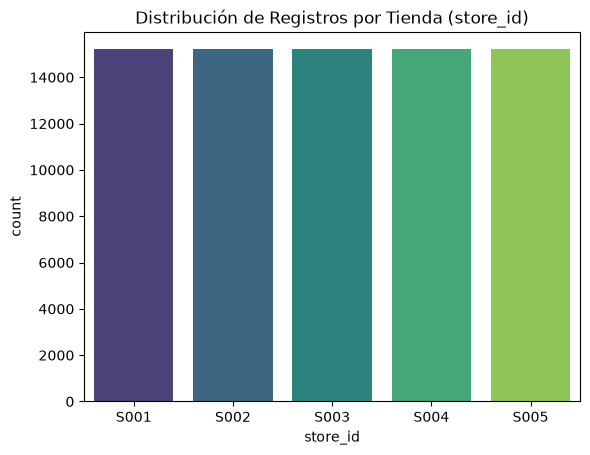

In [45]:
sns.barplot(data=df_cat['store_id'].value_counts().reset_index(), x='store_id', y='count', hue='store_id', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Tienda (store_id)')
plt.show()

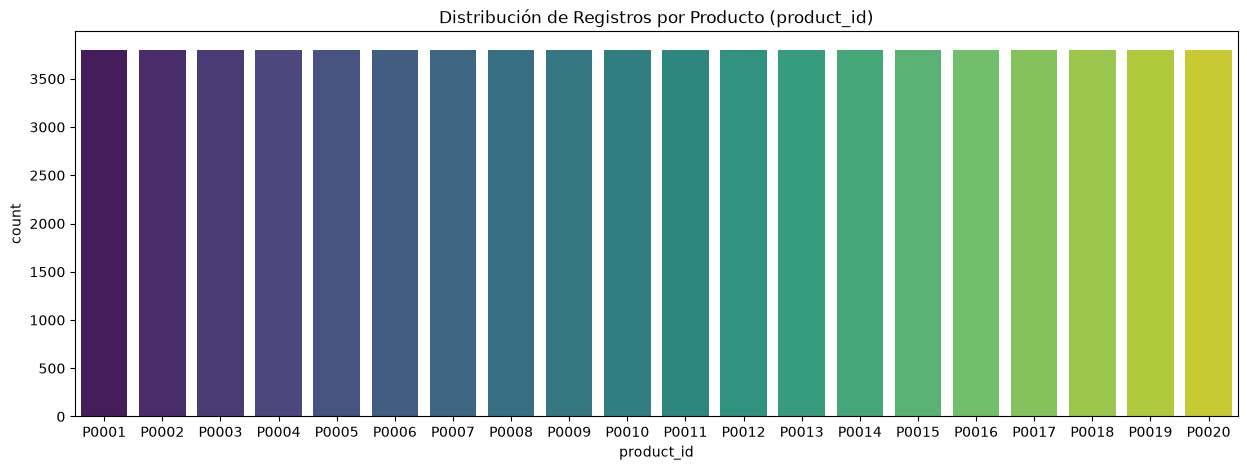

In [44]:
fig, ax = plt.subplots(figsize=(15,5))
sns.barplot(data=df_cat['product_id'].value_counts().reset_index(), x='product_id', y='count', hue='product_id', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Producto (product_id)')
plt.show()

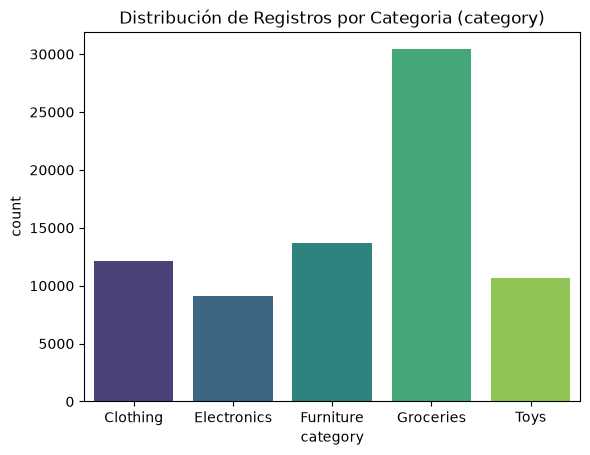

In [43]:
sns.barplot(data=df_cat['category'].value_counts().reset_index(), x='category', y='count', hue='category', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Categoria (category)')
plt.show()

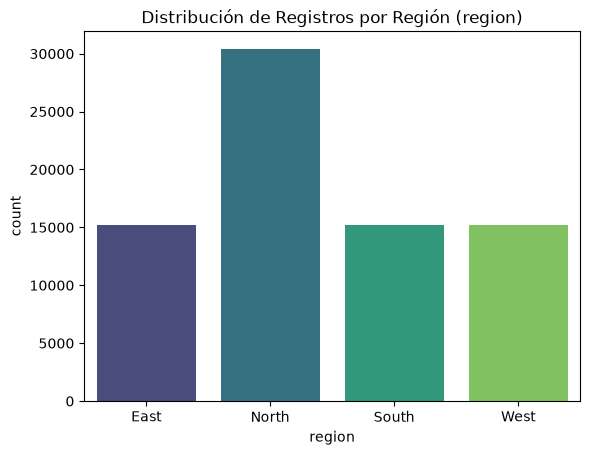

In [46]:
sns.barplot(data=df_cat['region'].value_counts().reset_index(), x='region', y='count', hue='region', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Región (region)')
plt.show()

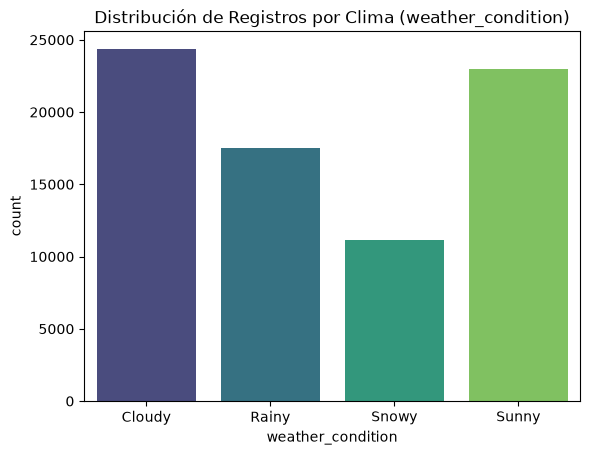

In [48]:
sns.barplot(data=df_cat['weather_condition'].value_counts().reset_index(), x='weather_condition', y='count', hue='weather_condition', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Clima (weather_condition)')
plt.show()

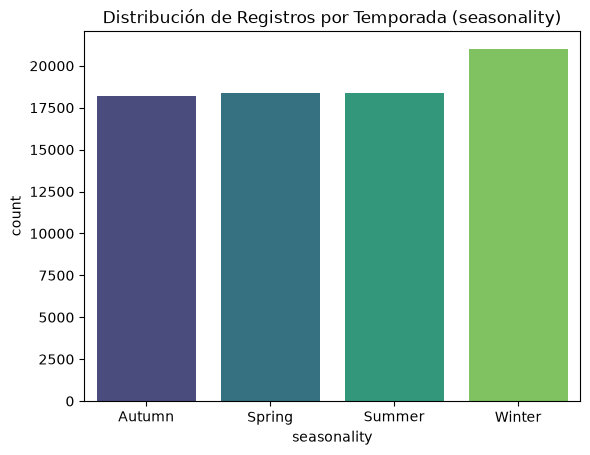

In [55]:
sns.barplot(data=df_cat['seasonality'].value_counts().reset_index(), x='seasonality', y='count', hue='seasonality', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Temporada (seasonality)')
plt.show()

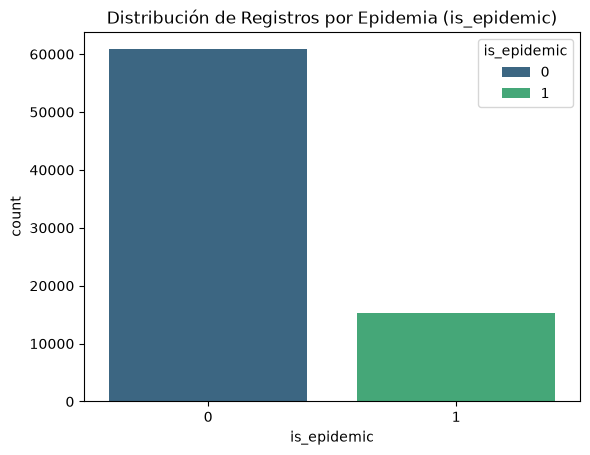

In [51]:
sns.barplot(data=df_cat['is_epidemic'].value_counts().reset_index(), x='is_epidemic', y='count', hue='is_epidemic', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Epidemia (is_epidemic)')
plt.show()

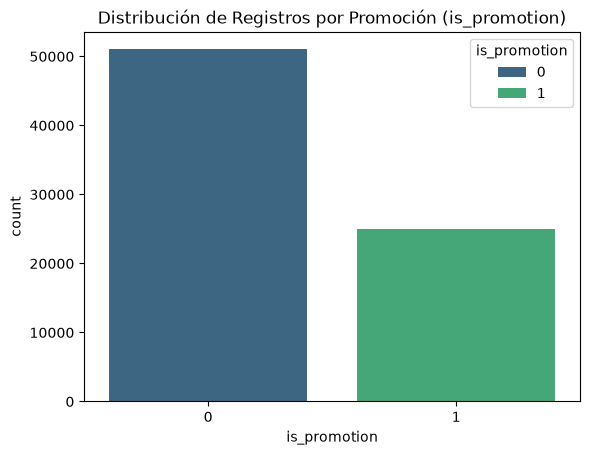

In [53]:
sns.barplot(data=df_cat['is_promotion'].value_counts().reset_index(), x='is_promotion', y='count', hue='is_promotion', palette='viridis', dodge = False)
plt.title('Distribución de Registros por Promoción (is_promotion)')
plt.show()

## III. Análisis Exploratorio Numérico
### Analisis Univariado

A continuación, se evalúa el comportamiento estadístico de las variables numéricas para identificar asimetrías, presencia de valores atípicos (*outliers*) y correlaciones iniciales.

---

In [57]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
inventory_level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
units_sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
units_ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
competitor_pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00
year,76000.0,2022.559211,0.570479,2022.00,2022.0000,2023.0,2023.0000,2024.00
month,76000.0,6.307895,3.546325,1.00,3.0000,6.0,9.0000,12.00
day,76000.0,15.711842,8.790894,1.00,8.0000,16.0,23.0000,31.00


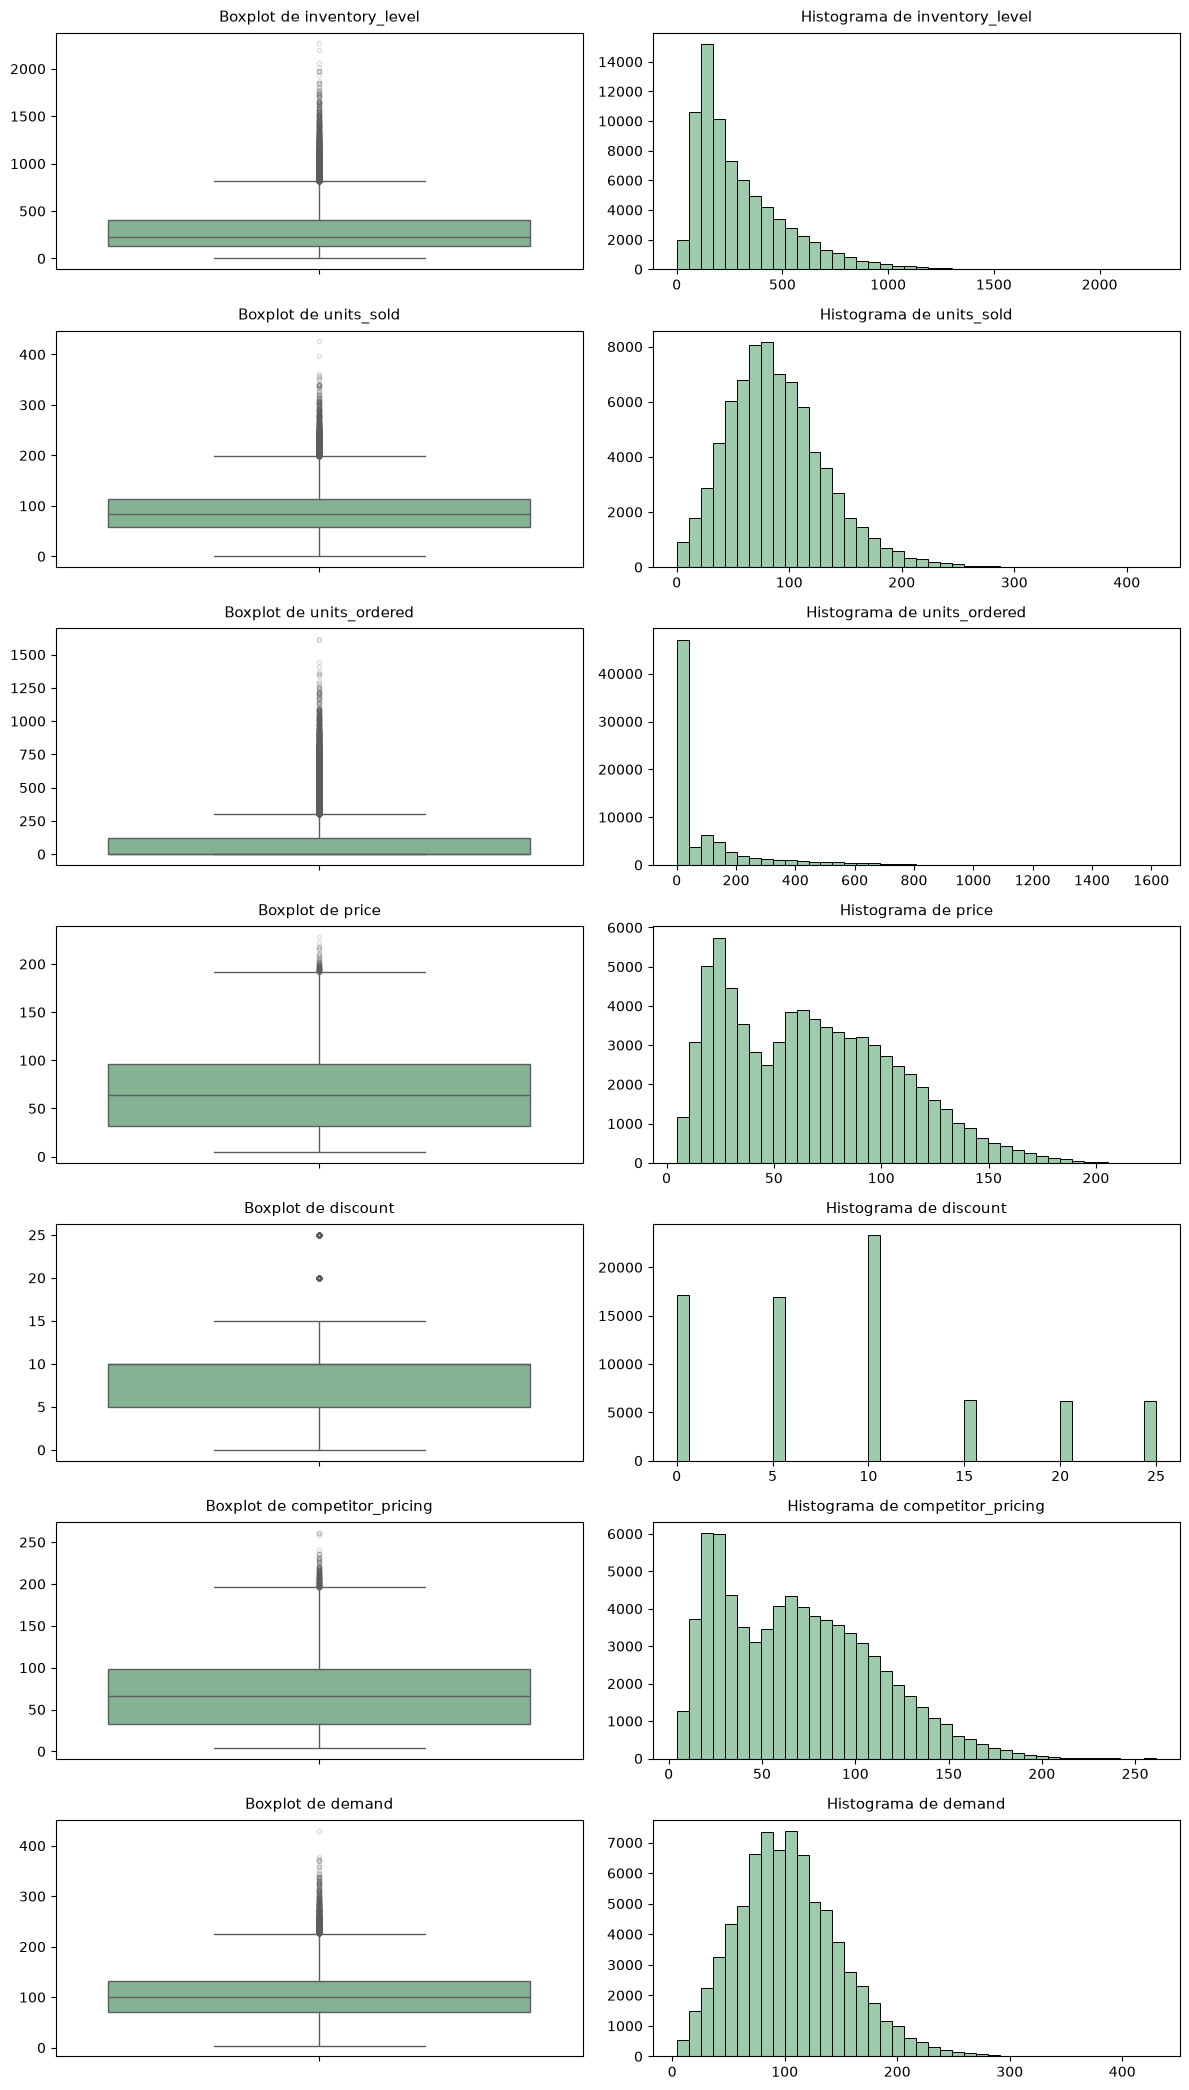

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_num = [col for col in df_num.columns if col not in ['year', 'month', 'day']]

sns.set_palette("crest")
fig, axes = plt.subplots(nrows=len(columnas_num), ncols=2, figsize=(12, 3 * len(columnas_num)))

for i, col in enumerate(columnas_num):
    sns.boxplot(data=df_num, y=col, ax=axes[i, 0], flierprops={'marker': 'o', 'alpha': 0.2, 'markersize': 3})
    axes[i, 0].set_title(f'Boxplot de {col}', fontsize=11, pad=8)
    axes[i, 0].set(xlabel='', ylabel='')
    
    sns.histplot(data=df_num, x=col, bins=40, ax=axes[i, 1])
    axes[i, 1].set_title(f'Histograma de {col}', fontsize=11, pad=8)
    axes[i, 1].set(xlabel='', ylabel='')

plt.tight_layout()
plt.show()